In [41]:
import numpy as np
import matplotlib.pyplot as plt
import time
from shapely import wkt
from shapely.geometry import Polygon

from py_wake.deficit_models.gaussian import BastankhahGaussian
from py_wake.examples.data.lillgrund import LillgrundSite
from py_wake.utils.gradients import autograd
from py_wake.examples.data.hornsrev1 import HornsrevV80

from topfarm.cost_models.cost_model_wrappers import CostModelComponent
from topfarm.easy_drivers import EasySGDDriver, EasyScipyOptimizeDriver
from topfarm.plotting import XYPlotComp
from topfarm.constraint_components.spacing import SpacingConstraint
from topfarm import TopFarmProblem
from topfarm.constraint_components.boundary import XYBoundaryConstraint
from topfarm.recorders import TopFarmListRecorder
from topfarm.constraint_components.constraint_aggregation import ConstraintAggregation
from topfarm.constraint_components.constraint_aggregation import DistanceConstraintAggregation

from py_wake.examples.data.iea37 import IEA37_WindTurbines, IEA37Site
from py_wake.examples.data.dtu10mw import DTU10MW

# Add these imports
from pyproj import Proj, transform


In [42]:
import numpy as np
import re
from shapely.geometry import Point, Polygon
import os

def vary_turbine_positions_from_files(turbine_filepath, boundary_filepath, output_filepath, perturbation_std_dev=0.0005):
    """
    Reads turbine and boundary data from files, generates varied turbine positions,
    and saves them to a new file.

    Args:
        turbine_filepath (str): The full path to the file with turbine coordinates.
        boundary_filepath (str): The full path to the file with the wind farm boundary WKT.
        output_filepath (str): The path where the new coordinates will be saved.
        perturbation_std_dev (float): Standard deviation for the random offset in decimal degrees.
                                      Default 0.0005 is ~55 meters (180 feet).

    Returns:
        np.ndarray: An array of the new, validated turbine [lon, lat] positions.
    """
    # --- 1. Read data from the specified files ---
    try:
        with open(turbine_filepath, 'r') as f:
            turbine_text = f.read()
        with open(boundary_filepath, 'r') as f:
            polygon_wkt = f.read()
    except FileNotFoundError as e:
        print(f"Error: Could not find a file. Please check your file paths.")
        print(f"Details: {e}")
        return None

    # --- 2. Parse the turbine positions from the file content ---
    initial_positions = []
    # Handles cases with or without a header, and extra whitespace
    for line in turbine_text.strip().split('\n'):
        # Simple regex to find floating point numbers, robust to different separators
        parts = re.findall(r'-?\d+\.\d+', line)
        if len(parts) == 2:
            initial_positions.append([float(parts[0]), float(parts[1])])
    initial_positions = np.array(initial_positions)
    print(f"Successfully read {len(initial_positions)} initial turbine positions.")

    # --- 3. Parse the WKT polygon to create a Shapely Polygon object ---
    try:
        # Extracts the coordinate pairs from the POLYGON string
        coords_str_match = re.search(r'\(\((.*)\)\)', polygon_wkt, re.DOTALL)
        if not coords_str_match:
            raise ValueError("Could not find coordinate pairs in the WKT polygon string.")
        
        coords_str = coords_str_match.group(1)
        # Split coordinates, handling potential extra spaces
        coord_pairs = [tuple(map(float, p.strip().split())) for p in coords_str.strip().split(',')]
        farm_polygon = Polygon(coord_pairs)
        print("Successfully parsed wind farm boundary.")
    except Exception as e:
        print(f"Error parsing the wind farm boundary WKT: {e}")
        return None

    # --- 4. Generate new positions using rejection sampling ---
    new_positions = []
    for i, (lon, lat) in enumerate(initial_positions):
        current_pos = Point(lon, lat)
        # Add a timeout to prevent infinite loops if a point is problematic
        attempts = 0
        while attempts < 1000:
            # Generate a random offset
            offset = np.random.normal(scale=perturbation_std_dev, size=2)
            candidate_pos = Point(current_pos.x + offset[0], current_pos.y + offset[1])

            # Check if the new point is within the farm boundary
            if farm_polygon.contains(candidate_pos):
                new_positions.append([candidate_pos.x, candidate_pos.y])
                break # Accepted, move to the next turbine
            attempts += 1
        
        if attempts >= 1000:
            print(f"Warning: Could not find a valid new position for turbine {i+1} at ({lon}, {lat}) after 1000 attempts. Keeping original position.")
            new_positions.append([lon, lat])


    final_positions = np.array(new_positions)

    # --- 5. Save the new coordinates to the output file ---
    try:
        # Use a high precision format to avoid rounding errors with lat/lon.
        # The 'header' argument has been removed to output only the coordinates.
        np.savetxt(output_filepath, final_positions, delimiter=",", fmt="%.15f")
        print(f"\nSuccessfully generated {len(final_positions)} new positions.")
        print(f"Updated coordinates have been saved to: {os.path.abspath(output_filepath)}")
    except Exception as e:
        print(f"Error saving the output file: {e}")

    return final_positions

# --- Main Execution ---
if __name__ == "__main__":
    # Define the file paths provided by the user
    # IMPORTANT: Replace these with the actual, correct paths on your system.
    turbine_file = "/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/TopFarm/coordinates.txt"
    boundary_file = "/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/TopFarm/wind farm coordinates.txt"
    
    # Define the name for the output file
    output_file = "updated_wind_turbine_coordinates.txt"

    # Run the main function
    vary_turbine_positions_from_files(turbine_file, boundary_file, output_file)



Successfully read 121 initial turbine positions.
Successfully parsed wind farm boundary.

Successfully generated 121 new positions.
Updated coordinates have been saved to: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/TopFarm/updated_wind_turbine_coordinates.txt


In [43]:
# Read the WKT polygon from the file
with open('/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/TopFarm/wind farm coordinates.txt', 'r') as file:
    wkt_polygon = file.read().strip()

# Parse the WKT polygon
polygon = wkt.loads(wkt_polygon)

# Read the turbine coordinates from the file
turbine_coords = np.loadtxt('/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/TopFarm/updated_wind_turbine_coordinates.txt', delimiter=',')

# Convert coordinates from EPSG:4326 to UTM zone 18N (appropriate for the US East Coast)
from pyproj import Proj, transform

# Define the coordinate reference systems
in_proj = Proj(init='epsg:4326')
out_proj = Proj(init='epsg:32618')  # UTM zone 18N - appropriate for your coordinates

# Convert boundary coordinates
boundary_coords = np.array(polygon.exterior.coords)
boundary = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in boundary_coords])

# Convert turbine coordinates
turbine_coords_utm = np.array([transform(in_proj, out_proj, lon, lat) for lon, lat in turbine_coords])
x0, y0 = turbine_coords_utm[:, 0], turbine_coords_utm[:, 1]

n_wt = x0.size

/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_1534/473885723.py:20: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#u

In [44]:
iea37 = IEA37_WindTurbines()
dtu10mw = DTU10MW()

In [45]:
# defining the site, wind turbines and wake model
site = LillgrundSite()
site.interp_method = 'linear'
windTurbines = dtu10mw
wake_model = BastankhahGaussian(site, windTurbines)

#wind resource
dirs = np.arange(0, 360, 1) #wind directions
ws = np.arange(3, 25, 1) # wind speeds
freqs = site.local_wind(x0, y0, wd=dirs, ws=ws).Sector_frequency_ilk[0, :, 0]     #sector frequency
As = site.local_wind(x0, y0, wd=dirs, ws=ws).Weibull_A_ilk[0, :, 0]               #weibull A
ks = site.local_wind(x0, y0, wd=dirs, ws=ws).Weibull_k_ilk[0, :, 0]               #weibull k

# objective function and gradient function
samps = 50    #number of samples

/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/py_wake/deficit_models/gaussian.py:124: UserWarning: The BastankhahGaussian model is not representative of the setup used in the literature. For this, use py_wake.literature.gaussian_models.Bastankhah_PorteAgel_2014 instead
  DeprecatedModel.__init__(self, 'py_wake.literature.gaussian_models.Bastankhah_PorteAgel_2014')


In [46]:
#function to create the random sampling of wind speed and wind directions
def sampling():
    idx = np.random.choice(np.arange(dirs.size), samps, p=freqs)
    wd = dirs[idx]
    A = As[idx]
    k = ks[idx]
    ws = A * np.random.weibull(k)
    return wd, ws

#aep function - SGD
def aep_func(x, y, full=False, **kwargs):
    # wd, ws = sampling()
    # aep_sgd = wake_model(x, y, wd=wd, ws=ws, time=True).aep().sum().values * 1e6
    # return aep_sgd
    return 0 # this doesn't change the performance of the driver

#gradient function - SGD
def aep_jac(x, y, **kwargs):
    wd, ws = sampling()
    jx, jy = wake_model.aep_gradients(gradient_method=autograd, wrt_arg=['x', 'y'], x=x, y=y, ws=ws, wd=wd, time=True)
    daep_sgd = np.array([np.atleast_2d(jx), np.atleast_2d(jy)]) * 1e6
    return daep_sgd

#aep function - SLSQP
def aep_func2(x, y, **kwargs):
    wd = np.arange(0, 360, 0.5)
    ws = np.arange(3, 25, 0.5)
    aep_slsqp = wake_model(x, y, wd=wd, ws=ws).aep().sum().values * 1e6
    return aep_slsqp

#gradient function - SLSQP
def aep_jac2(x, y, **kwargs):
    wd = np.arange(0, 360, 0.5)
    ws = np.arange(3, 25, 0.5)
    jx, jy = wake_model.aep_gradients(gradient_method=autograd, wrt_arg=['x', 'y'], x=x, y=y, ws=ws, wd=wd, time=False)
    daep_slsqp = np.array([np.atleast_2d(jx), np.atleast_2d(jy)]) * 1e6
    return daep_slsqp

In [47]:
#aep component - SGD
aep_comp = CostModelComponent(input_keys=['x','y'], n_wt=n_wt, cost_function=aep_func, objective=True, cost_gradient_function=aep_jac, maximize=True)

#aep component - SLSQP
aep_comp2 = CostModelComponent(input_keys=['x','y'], n_wt=n_wt, cost_function=aep_func2, objective=True, cost_gradient_function=aep_jac2, maximize=True)

cost_comps = [aep_comp2, aep_comp]

# Define sgd_iterations
sgd_iterations = 100

min_spacing_m = 5 * windTurbines.diameter()  #minimum inter-turbine spacing in meters
# Define the boundary constraint with the correct type
constraint_comp = XYBoundaryConstraint(boundary, 'polygon')  # Ensure 'polygon' is used

# Define the constraints list correctly
constraints = [
    [SpacingConstraint(min_spacing_m), constraint_comp],
    [SpacingConstraint(min_spacing_m), constraint_comp]  # Changed from DistanceConstraintAggregation
]

#driver specs
driver_names = ['SLSQP', 'SGD']
drivers = [EasyScipyOptimizeDriver(maxiter=30, tol=1e-3),
           EasySGDDriver(maxiter=sgd_iterations, learning_rate=windTurbines.diameter()/5, gamma_min_factor=0.1)]

driver_no = 1    #SGD driver
ec = [10,1]      #expected cost for SLSQP (10) and SGD (1) drivers

INFO: checking out_of_order...
INFO:     out_of_order check complete (0.000071 sec).
INFO: checking system...
INFO:     system check complete (0.000005 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000048 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check complete (0.000011 sec).
INFO: checking missing_recorders...
INFO:     missing_recorders check complete (0.000001 sec).
INFO: checking unserializable_options...
INFO:     unserializable_options check complete (0.000053 sec).
INFO: checking comp_has_no_outputs...
INFO:     comp_has_no_outputs check complete (0.000011 sec).
INFO: checking auto_ivc_warnings...
INFO:     auto_ivc_warnings check complete (0.000001 sec).
INFO: checking out_of_order...
INFO:     out_of_order check complete (0.000050 sec).
INFO: checking system...
INFO:     system check complete (0.000005 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000040 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check com

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


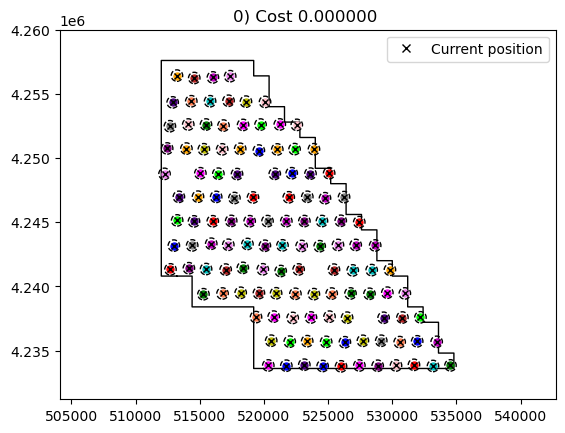

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Optimization with SGD took: 49s  with a total constraint violation of  2674670.275071284


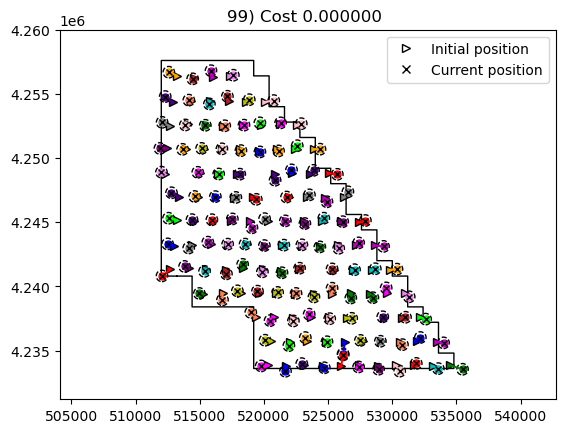

In [48]:
# Ensure the correct constraints are applied in the TopFarmProblem
tf = TopFarmProblem(
    design_vars={'x': x0, 'y': y0},
    cost_comp=cost_comps[driver_no],
    constraints=constraints[driver_no],
    driver=drivers[driver_no],
    plot_comp=XYPlotComp(),
    expected_cost=ec[driver_no]
)

tic = time.time()
cost, state, recorder = tf.optimize()
toc = time.time()
print('Optimization with SGD took: {:.0f}s'.format(toc-tic), ' with a total constraint violation of ', recorder['constraint_violation'][-1])
recorder.save(f'{driver_names[driver_no]}')

In [49]:
# driver_no = 0  # SLSQP

# tf = TopFarmProblem(
#     design_vars={"x": x0, "y": y0},
#     cost_comp=cost_comps[driver_no],
#     constraints=constraints[driver_no],
#     driver=drivers[driver_no],
#     plot_comp=XYPlotComp(),
#     expected_cost=ec[driver_no],
#     max_time=300
# )

# tic = time.time()
# cost, state, recorder = tf.optimize()
# toc = time.time()
# print("Optimization with SLSQP took: {:.0f}s".format(toc - tic))
# recorder.save(f"{driver_names[driver_no]}")

In [50]:
# plt.figure(figsize=(10, 6))
# rec = TopFarmListRecorder().load(f'SGD')

# # Calculate AEP for each step in the optimization
# aep = []
# for x, y in zip(rec['x'], rec['y']):
#     aep.append(aep_func2(x, y))

# # Calculate improvement percentage
# improvement = (aep[-1] - aep[0]) / aep[0] * 100
# print(f'SGD AEP improvement: {improvement:.2f}%')

# # Plot the AEP over time
# plt.plot(rec['timestamp']-rec['timestamp'][0], aep, label='SGD', linewidth=2)

# plt.legend()
# plt.xlabel('Time [s]')
# plt.ylabel('Annual Energy Production (AEP)')
# plt.title('AEP Improvement During Optimization')
# plt.grid(True, linestyle='--', alpha=0.7)

# # Add a text annotation showing the improvement percentage
# plt.annotate(f'Improvement: {improvement:.2f}%', 
#              xy=(0.05, 0.95), 
#              xycoords='axes fraction',
#              bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="orange", alpha=0.8))

# plt.tight_layout()
# plt.show()

In [51]:
# plt.figure()
# for i in range(2):
#     rec = TopFarmListRecorder().load(f'recordings/{driver_names[i]}')
#     if driver_names[i] == 'SGD':
#         aep = []
#         for x, y in zip(rec['x'], rec['y']):
#             aep.append(aep_func2(x, y))
#         print('SGD AEP improvement: {:.2f}%'.format((aep[-1] - aep[0]) / aep[0] * 100))
#     else:
#         aep = rec['Cost']
#         print('SLSQP AEP improvement: {:.2f}%'.format((aep[-1] - aep[0]) / aep[0] * 100))
#     plt.plot(rec['timestamp']-rec['timestamp'][0], aep, label=driver_names[i])
# plt.legend()
# plt.xlabel('time [s]')
# plt.ylabel('AEP')